# 4. Zero-shot CLIP

CLIP ViT-B/32 и прогоняем test split PetFaces.

Промпты — ансамбль шаблонов, эмбеддинги классов усредняем. Это обычно стабильнее, чем один `"a photo of a {breed}"`.

Сравниваю с чекпоинтами из частей 1–2, если они уже посчитаны.


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

import petsdata as P

P.set_seed(P.SEED)
device = P.get_device()

import clip
print("clip ok", device)


clip ok mps


In [3]:
train_df, val_df, test_df, breed2id = P.ensure_splits()
id2breed = {i: b for b, i in breed2id.items()}
names = [id2breed[i] for i in range(len(breed2id))]
pretty = [P.pretty_label(n) for n in names]
species_of = (
    pd.concat([train_df, val_df, test_df])
    .groupby("breed_id")["species"]
    .agg(lambda s: s.mode().iloc[0])
    .to_dict()
)

TEMPLATES = [
    "a photo of a {p}",
    "a close-up photo of a {p} face",
    "a pet portrait of a {p}",
    "a snapshot of a {sp} named {p}",
    "headshot of a {p}, studio lighting",
]


def build_text_features(model, breed_names):
    feats = []
    for breed in breed_names:
        p = P.pretty_label(breed)
        sp = species_of[names.index(breed)]
        tok = clip.tokenize([t.format(p=p, sp=sp) for t in TEMPLATES]).to(device)
        with torch.no_grad():
            f = model.encode_text(tok)
            f = f / f.norm(dim=-1, keepdim=True)
            f = f.mean(0)
            f = f / f.norm()
        feats.append(f)
    return torch.stack(feats, 0)


In [4]:
clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
text_f = build_text_features(clip_model, names)
print("text features", tuple(text_f.shape))


100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 47.7MiB/s]


text features (37, 512)


In [5]:
@torch.no_grad()
def predict_clip(frame):
    ys = []
    ps = []
    for _, row in tqdm(frame.iterrows(), total=len(frame)):
        img = preprocess(Image.open(row["path"]).convert("RGB")).unsqueeze(0).to(device)
        feat = clip_model.encode_image(img)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        logits = 100.0 * feat @ text_f.T
        prob = logits.softmax(-1).cpu().numpy()[0]
        ys.append(int(row["breed_id"]))
        ps.append(prob)
    y = np.array(ys)
    p = np.stack(ps)
    hat = p.argmax(1)
    top3 = np.sort(np.argsort(-p, axis=1)[:, :3])
    # top3 accuracy
    t3 = np.array([yi in row for yi, row in zip(y, np.argsort(-p, axis=1)[:, :3])])
    return y, p, hat, t3.mean()


y, prob, hat, top3 = predict_clip(test_df)
top1 = (hat == y).mean()
print(f"CLIP zero-shot  top-1 {top1:.4f}  top-3 {top3:.4f}")

b2s = (
    pd.concat([train_df, val_df, test_df])
    .groupby("breed_id")["species_id"]
    .agg(lambda s: int(s.mode().iloc[0]))
    .to_dict()
)
sp_hat = np.array([b2s[int(i)] for i in hat])
print("species via CLIP breed:", (sp_hat == test_df["species_id"].values).mean())

print(classification_report(y, hat, target_names=pretty, zero_division=0))


100%|██████████| 482/482 [00:03<00:00, 132.90it/s]

CLIP zero-shot  top-1 0.7780  top-3 0.9481
species via CLIP breed: 1.0
                            precision    recall  f1-score   support

                Abyssinian       0.61      0.79      0.69        14
                    Bengal       0.00      0.00      0.00        11
                    Birman       0.33      1.00      0.49        14
                    Bombay       0.00      0.00      0.00        13
         British Shorthair       0.67      0.67      0.67        15
              Egyptian Mau       0.52      1.00      0.69        11
                Maine Coon       0.75      0.86      0.80        14
                   Persian       0.00      0.00      0.00        14
                   Ragdoll       1.00      0.27      0.42        15
              Russian Blue       0.58      1.00      0.73        15
                   Siamese       0.75      0.40      0.52        15
                    Sphynx       1.00      1.00      1.00        15
          american bulldog       0.78      1

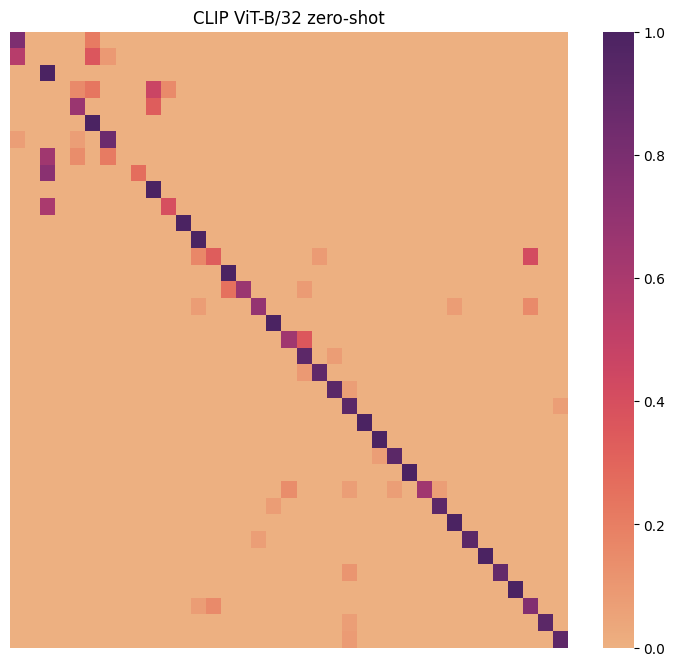

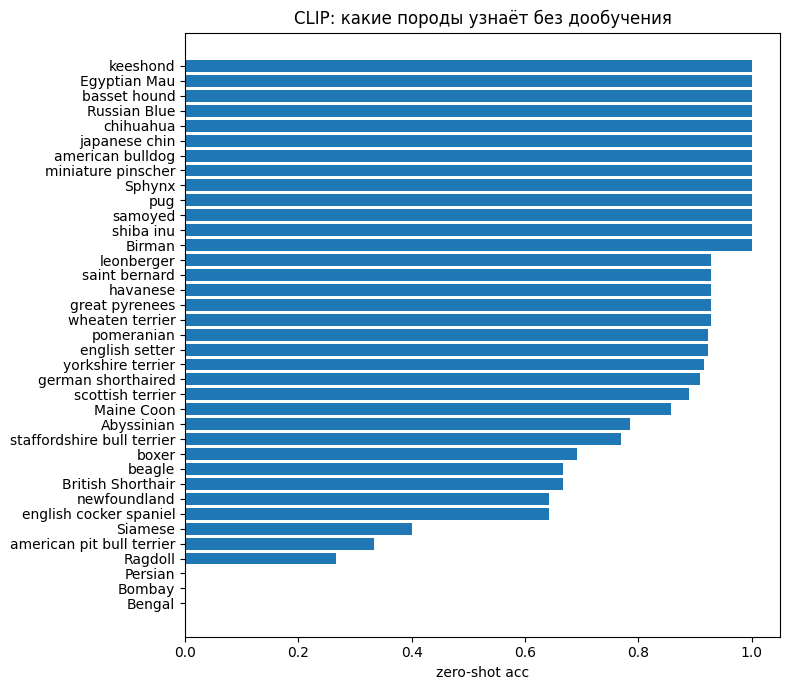

In [6]:
cm = confusion_matrix(y, hat, labels=np.arange(len(names)))
cm_n = cm / np.clip(cm.sum(1, keepdims=True), 1, None)
plt.figure(figsize=(9, 8))
sns.heatmap(cm_n, cmap="flare", xticklabels=False, yticklabels=False, vmin=0, vmax=1)
plt.title("CLIP ViT-B/32 zero-shot")
plt.show()

# per-class
per = []
for i, name in enumerate(pretty):
    mask = y == i
    if mask.sum() == 0:
        continue
    per.append({"breed": name, "acc": (hat[mask] == i).mean(), "n": int(mask.sum())})
per = pd.DataFrame(per).sort_values("acc")
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(per["breed"], per["acc"])
ax.set_xlabel("zero-shot acc")
ax.set_title("CLIP: какие породы узнаёт без дообучения")
plt.tight_layout()
plt.show()


Тот же CLIP на полных кадрах Oxford-IIIT (`images1`) — проверка, что модель не завязана на кроп морды.


In [7]:
oxford = P.scan_oxford()
oxford = oxford[oxford["breed"].isin(names)].copy()
oxford["breed_id"] = oxford["breed"].map(breed2id)
oxford["species_id"] = oxford["species"].map({"cat": 0, "dog": 1})
# подвыборка, иначе 7k долго
rng = np.random.default_rng(P.SEED)
idx = rng.choice(len(oxford), size=min(800, len(oxford)), replace=False)
ox_s = oxford.iloc[idx].reset_index(drop=True)
y2, _, hat2, t3b = predict_clip(ox_s)
print(f"CLIP on full-body Oxford subset  top-1 {(hat2==y2).mean():.4f}  top-3 {t3b:.4f}  n={len(ox_s)}")


100%|██████████| 800/800 [00:05<00:00, 140.78it/s]

CLIP on full-body Oxford subset  top-1 0.8400  top-3 0.9525  n=800


Сводка, если лежат чекпоинты сверток.


In [8]:
rows = [{"model": "CLIP ViT-B/32 zero-shot", "top1": float(top1), "top3": float(top3)}]

ckpt_s = P.CKPT_DIR / "faceirnet.pt"
ckpt_t = P.CKPT_DIR / "effnet_b0.pt"
if ckpt_s.exists():
    rows.append({"model": "FaceIRNet (scratch, val best)", "top1": None, "note": str(ckpt_s)})
if ckpt_t.exists():
    rows.append({"model": "EfficientNet-B0 ft (val best)", "top1": None, "note": str(ckpt_t)})

print(pd.DataFrame(rows).to_string(index=False))
print("\nцифры CNN смотри в ноутбуках 01/02 — CLIP специально без дообучения.")


                        model     top1     top3                                                            note
      CLIP ViT-B/32 zero-shot 0.778008 0.948133                                                             NaN
FaceIRNet (scratch, val best)      NaN      NaN /Users/mnfom/Projects/cnn-Makarena-211/checkpoints/faceirnet.pt
EfficientNet-B0 ft (val best)      NaN      NaN /Users/mnfom/Projects/cnn-Makarena-211/checkpoints/effnet_b0.pt

цифры CNN смотри в ноутбуках 01/02 — CLIP специально без дообучения.
